In [84]:
def calculate_inlet_velocity(
    flow_rate,
    inlet_diameter,
    breeder_density,
    breeder,
    suppress_print=False,
):
    """Calculate the inlet velocity of fluid breeder at a given flow rate, inlet diameter, breeder density, and temperature.
    Used for OpenFOAM simulation.

    Parameters
    ----------
    flow_rate : float
        Flow rate in kg/s.
    inlet_diameter : float
        Inlet diameter in m.
    breder_density : float
        Breeder fluid density in kg/m3.
    breeder : str
        Breeder fluid name.

    Returns
    -------
    float
        Inlet velocity in m/s.
    """

    inlet_area = np.pi * (inlet_diameter / 2) ** 2  # m^2

    inlet_velocity = flow_rate * breeder_density ** (-1) * inlet_area ** (-1)  # m/s
    if not suppress_print:
        print(
            f"Inlet velocity for {breeder} flow rate of {flow_rate}kg/s is {inlet_velocity}m/s."
        )

    return inlet_velocity

In [101]:
from autoemulate.simulations.base import Simulator
import numpy as np

N_A = 6.0221e23 # atms/mol

class FestimProblem(Simulator):
    def _forward(self):
        pass

inlet_diameter = 9.2e-3  # m 
breeder_temperature = 723.15  # K from Utili 2023
LiPb_density = (
    10520.35 - 1.19051 * breeder_temperature
)  # kg/m3 ; equation from Martelli 2019
min_velocity = calculate_inlet_velocity(flow_rate=0.2,inlet_diameter=inlet_diameter, breeder_density=LiPb_density, breeder="lipb", suppress_print=True)

simulator = FestimProblem(
    parameters_range={
        "c_in": (np.log10(1e16/N_A), np.log10(1e25/N_A)),
        "v_in": (min_velocity, 0.97), # from https://doi.org/10.3390/en16073022, 0.2-4.6 kg/s, min vel about 0.3m/s
        "bend_radius": (0.02,0.2),
        "length": (0.5,1.1),
    },  # ranges for each variable
    output_names=["c_out", "permeation_flux"],
)

In [102]:
# load training data 

training_data_folder = "/home/kaelyn/Fusion-TES-Modeling/lipb_emulators/parametric_mesh/trained"
X = np.loadtxt(f"{training_data_folder}/trained_inputs.csv", delimiter=",") 
Y = np.loadtxt(f"{training_data_folder}/trained_outputs.csv", delimiter=",") 

In [103]:
# train model 
from autoemulate.emulators import GaussianProcessRBF

def make_gp(x_train, y_train, lr=5e-2):
    return GaussianProcessRBF(
        x_train, 
        y_train, 
        lr=lr, 
        standardize_y=False,
    )

# train initial emulator 
print("training initial emulator...")
emulator = make_gp(X,Y, 0.1)
emulator.fit(X,Y)
print("emulator trained!")

training initial emulator...
emulator trained!


creating mean and variance plots...


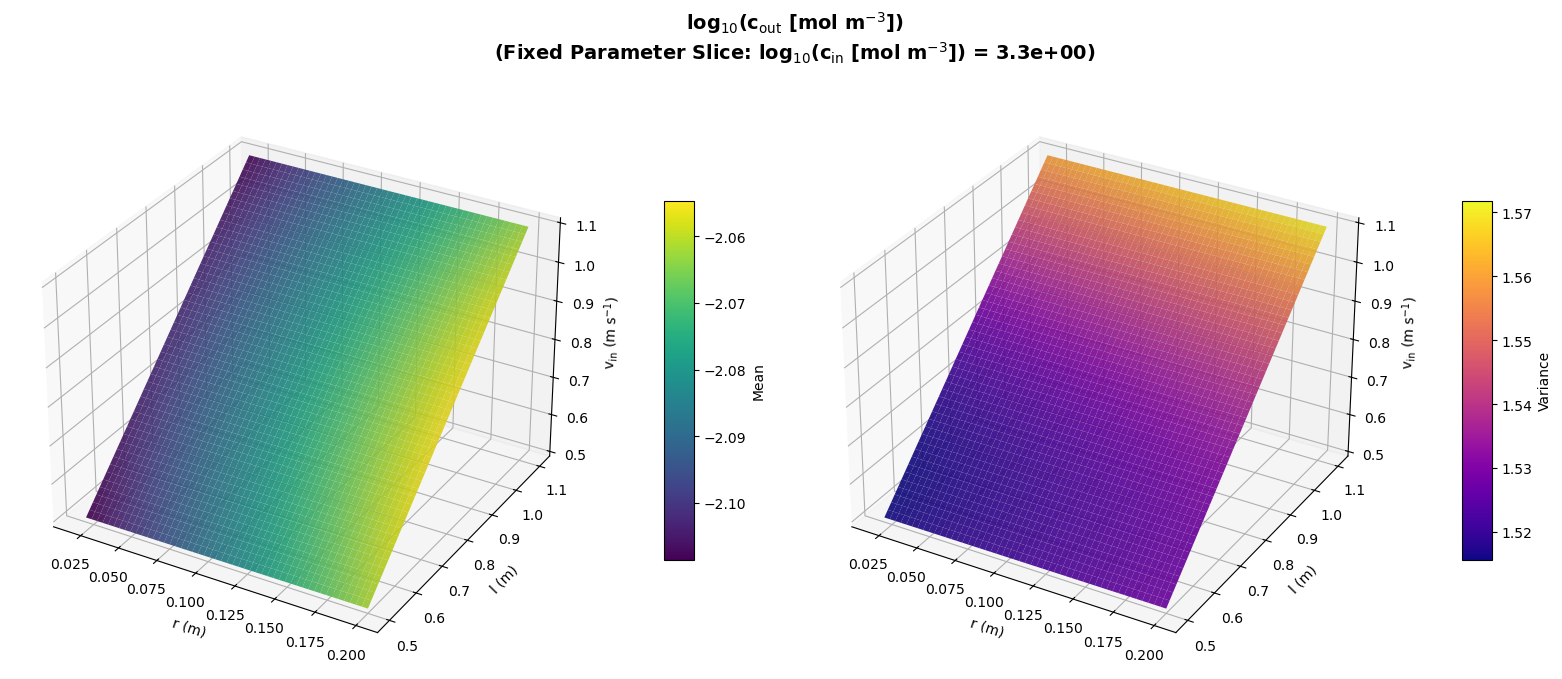

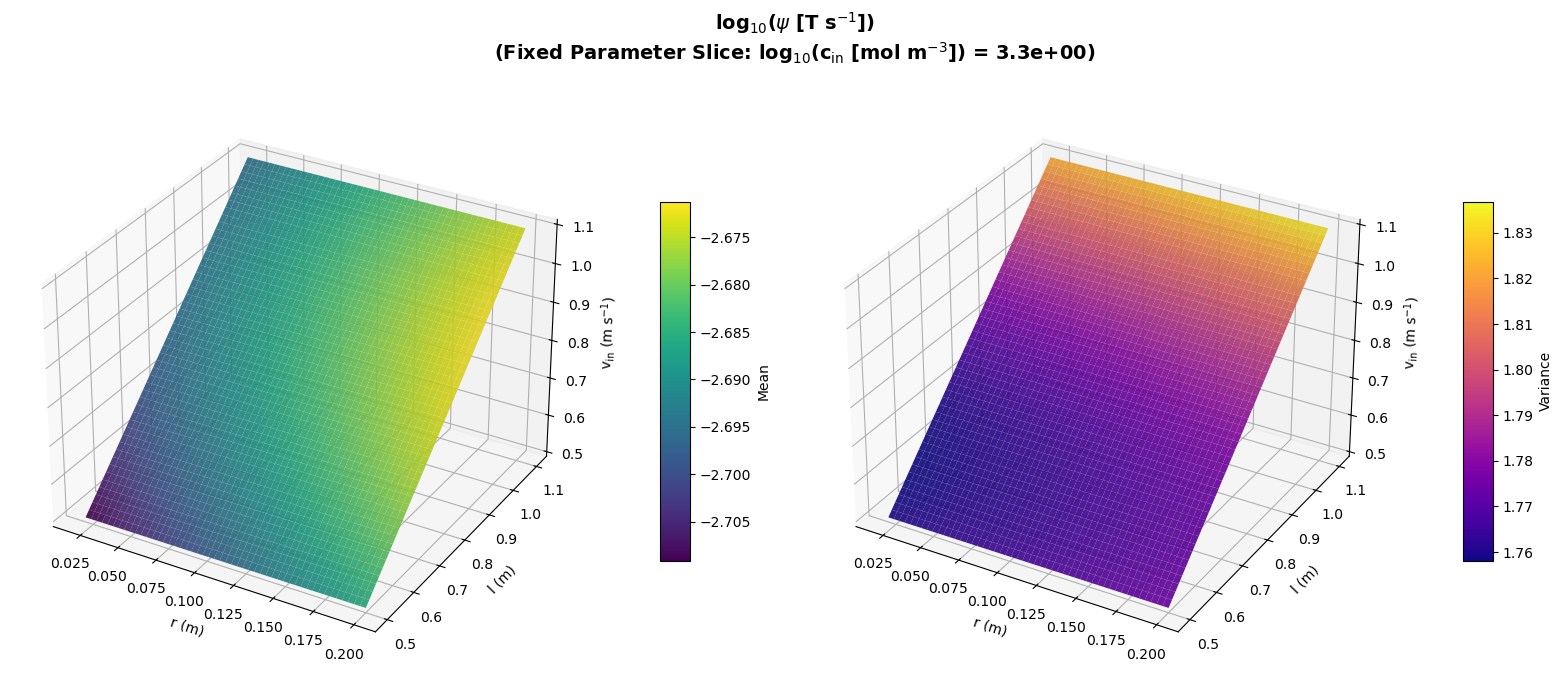

Plotting complete!


In [104]:
## FIXED C_IN 3D MEAN/VARIANCE PLOTS

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch

print("creating mean and variance plots...")

param_bounds = {
    "bend_radius": (0.02, 0.2),
    "length": (0.5, 1.1),
    "v_in": (min_velocity, 0.97),
    "c_in": (np.log10(1e16/N_A), np.log10(1e25/N_A))
}

active_x = "bend_radius"
active_y = "length"
active_z = "length"      

# fixed c_in for these
fixed_params = ["c_in"]
fixed_vals = {p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params}


# make 2D mesh grid
grid_res = 50  
x_space = np.linspace(param_bounds[active_x][0], param_bounds[active_x][1], grid_res)
y_space = np.linspace(param_bounds[active_y][0], param_bounds[active_y][1], grid_res)
X_grid, Y_grid = np.meshgrid(x_space, y_space)

# z-grid of same shape as x and y
z_space = np.linspace(param_bounds[active_z][0], param_bounds[active_z][1], grid_res)
Z_grid = np.repeat(z_space[:, np.newaxis], grid_res, axis=1)

# make trained data array
total_samples = X_grid.size
X_pred = np.zeros((total_samples, 4))
X_pred[:, 0] = X_grid.flatten()
X_pred[:, 1] = Y_grid.flatten()
X_pred[:, 2] = Z_grid.flatten()
X_pred[:, 3] = fixed_vals["c_in"]

# predict mean and variance needs a torch 
X_pred_tensor = torch.from_numpy(X_pred).float()
mean_tensor, var_tensor = emulator.predict_mean_and_variance(X_pred_tensor)

# convert back to numpy
mean_pred = mean_tensor.detach().cpu().numpy()
var_pred = var_tensor.detach().cpu().numpy()

mean_grid_out1 = mean_pred[:, 0].reshape(grid_res, grid_res)
mean_grid_out2 = mean_pred[:, 1].reshape(grid_res, grid_res)
var_grid_out1 = var_pred[:, 0].reshape(grid_res, grid_res)
var_grid_out2 = var_pred[:, 1].reshape(grid_res, grid_res)

outputs_to_render = [
    {"title": r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])", "mean": mean_grid_out1, "var": var_grid_out1},
    {"title": r"log$_{10}$($\psi$ [T s$^{-1}$])", "mean": mean_grid_out2, "var": var_grid_out2}
]

# plotting
for out in outputs_to_render:
    fig = plt.figure(figsize=(16, 7))
    
    # mean plot
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    
    norm_mean = (out["mean"] - np.min(out["mean"])) / (np.max(out["mean"]) - np.min(out["mean"]) + 1e-12)
    surf1 = ax1.plot_surface(X_grid, Y_grid, Z_grid, facecolors=cm.viridis(norm_mean),
                             linewidth=0, antialiased=True, alpha=0.9)
    ax1.set_xlabel(r"r (m)", fontsize=10)
    ax1.set_ylabel(r"l (m)", fontsize=10)
    ax1.set_zlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)", fontsize=10)
    
    m1 = cm.ScalarMappable(cmap=cm.viridis)
    m1.set_array(out["mean"])
    fig.colorbar(m1, ax=ax1, shrink=0.6, aspect=12, pad=0.1, label="Mean")
    
    # variance plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    
    norm_var = (out["var"] - np.min(out["var"])) / (np.max(out["var"]) - np.min(out["var"]) + 1e-12)
    surf2 = ax2.plot_surface(X_grid, Y_grid, Z_grid, facecolors=cm.plasma(norm_var),
                             linewidth=0, antialiased=True, alpha=0.9)
    ax2.set_xlabel(r"r (m)", fontsize=10)
    ax2.set_ylabel(r"l (m)", fontsize=10)
    ax2.set_zlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)", fontsize=10)
    
    m2 = cm.ScalarMappable(cmap=cm.plasma)
    m2.set_array(out["var"])
    fig.colorbar(m2, ax=ax2, shrink=0.6, aspect=12, pad=0.1, label="Variance")
    
    subtitle_details = r"Fixed Parameter Slice: log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$]) ="+f" {fixed_vals["c_in"]:.1e}"
    fig.suptitle(f"{out['title']}\n({subtitle_details})", fontsize=14, weight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()

print("Plotting complete!")


creating mean and variance plots...


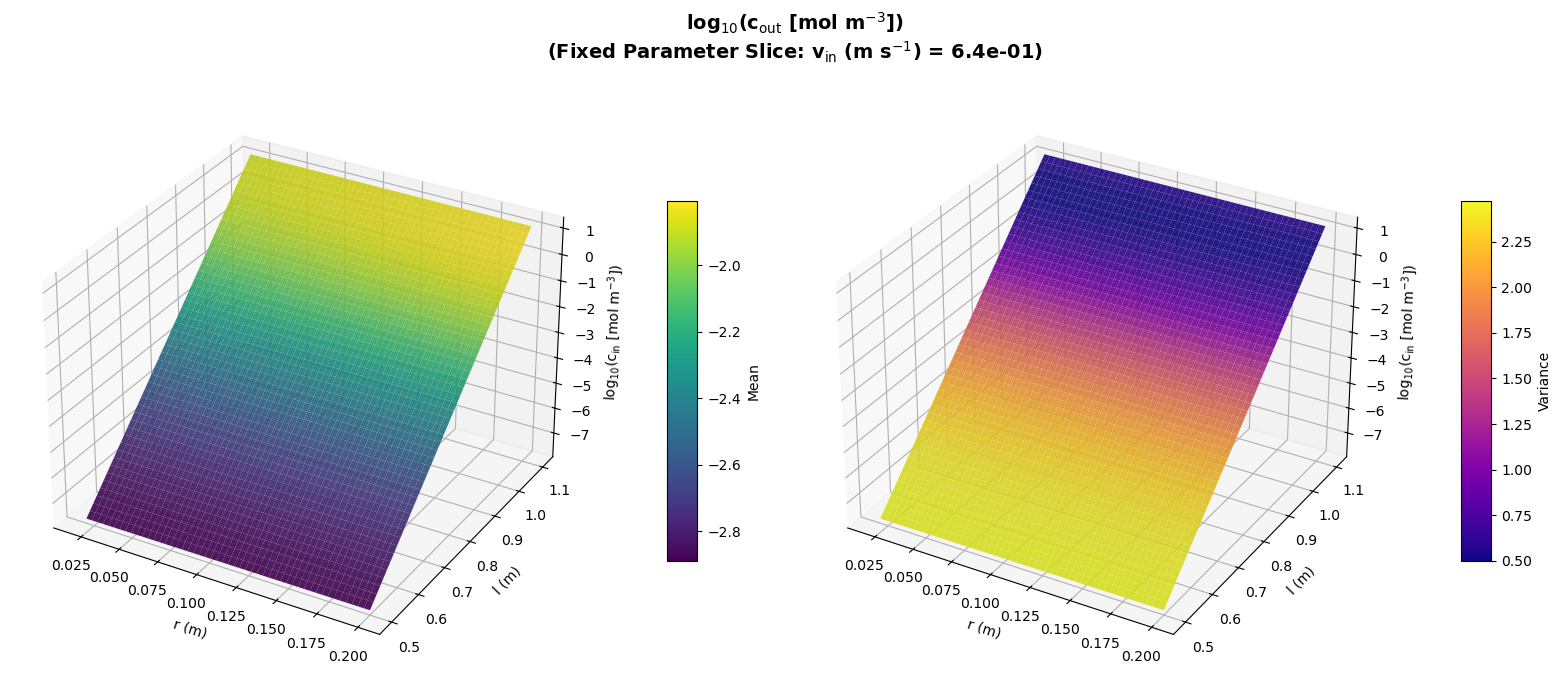

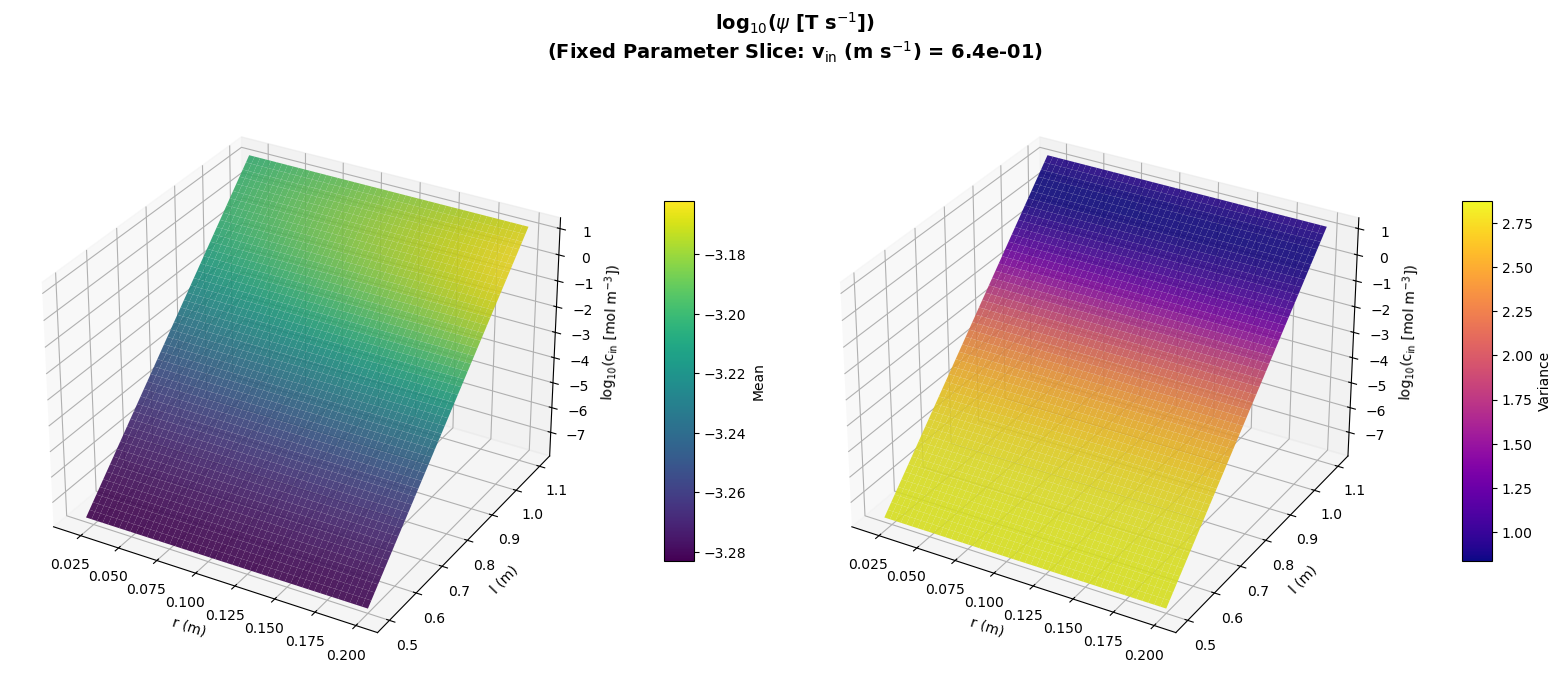

Plotting complete!


In [105]:
## FIXED v_in 3D MEAN/VARIANCE PLOTS

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch

print("creating mean and variance plots...")

param_bounds = {
    "bend_radius": (0.02, 0.2),
    "length": (0.5, 1.1),
    "v_in": (min_velocity, 0.97),
    "c_in": (np.log10(1e16/N_A), np.log10(1e25/N_A))
}

active_x = "bend_radius"
active_y = "length"
active_z = "c_in"      

# fixed v_in for these
fixed_params = ["v_in"]
fixed_vals = {p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params}


# make 2D mesh grid
grid_res = 50  
x_space = np.linspace(param_bounds[active_x][0], param_bounds[active_x][1], grid_res)
y_space = np.linspace(param_bounds[active_y][0], param_bounds[active_y][1], grid_res)
X_grid, Y_grid = np.meshgrid(x_space, y_space)

# z-grid of same shape as x and y
z_space = np.linspace(param_bounds[active_z][0], param_bounds[active_z][1], grid_res)
Z_grid = np.repeat(z_space[:, np.newaxis], grid_res, axis=1)

# make trained data array
total_samples = X_grid.size
X_pred = np.zeros((total_samples, 4))
X_pred[:, 0] = X_grid.flatten()
X_pred[:, 1] = Y_grid.flatten()
X_pred[:, 2] = Z_grid.flatten()
X_pred[:, 3] = fixed_vals["v_in"]

# predict mean and variance needs a torch 
X_pred_tensor = torch.from_numpy(X_pred).float()
mean_tensor, var_tensor = emulator.predict_mean_and_variance(X_pred_tensor)

# convert back to numpy
mean_pred = mean_tensor.detach().cpu().numpy()
var_pred = var_tensor.detach().cpu().numpy()

mean_grid_out1 = mean_pred[:, 0].reshape(grid_res, grid_res)
mean_grid_out2 = mean_pred[:, 1].reshape(grid_res, grid_res)
var_grid_out1 = var_pred[:, 0].reshape(grid_res, grid_res)
var_grid_out2 = var_pred[:, 1].reshape(grid_res, grid_res)

outputs_to_render = [
    {"title": r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])", "mean": mean_grid_out1, "var": var_grid_out1},
    {"title": r"log$_{10}$($\psi$ [T s$^{-1}$])", "mean": mean_grid_out2, "var": var_grid_out2}
]

# plotting
for out in outputs_to_render:
    fig = plt.figure(figsize=(16, 7))
    
    # mean plot
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    
    norm_mean = (out["mean"] - np.min(out["mean"])) / (np.max(out["mean"]) - np.min(out["mean"]) + 1e-12)
    surf1 = ax1.plot_surface(X_grid, Y_grid, Z_grid, facecolors=cm.viridis(norm_mean),
                             linewidth=0, antialiased=True, alpha=0.9)
    ax1.set_xlabel(r"r (m)", fontsize=10)
    ax1.set_ylabel(r"l (m)", fontsize=10)
    ax1.set_zlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])", fontsize=10)
    
    m1 = cm.ScalarMappable(cmap=cm.viridis)
    m1.set_array(out["mean"])
    fig.colorbar(m1, ax=ax1, shrink=0.6, aspect=12, pad=0.1, label="Mean")
    
    # variance plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    
    norm_var = (out["var"] - np.min(out["var"])) / (np.max(out["var"]) - np.min(out["var"]) + 1e-12)
    surf2 = ax2.plot_surface(X_grid, Y_grid, Z_grid, facecolors=cm.plasma(norm_var),
                             linewidth=0, antialiased=True, alpha=0.9)
    ax2.set_xlabel(r"r (m)", fontsize=10)
    ax2.set_ylabel(r"l (m)", fontsize=10)
    ax2.set_zlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])", fontsize=10)
    
    m2 = cm.ScalarMappable(cmap=cm.plasma)
    m2.set_array(out["var"])
    fig.colorbar(m2, ax=ax2, shrink=0.6, aspect=12, pad=0.1, label="Variance")
    
    subtitle_details = r"Fixed Parameter Slice: v$_{\mathrm{in}}$ (m s$^{-1}$) ="+f" {fixed_vals["v_in"]:.1e}"
    fig.suptitle(f"{out['title']}\n({subtitle_details})", fontsize=14, weight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()

print("Plotting complete!")


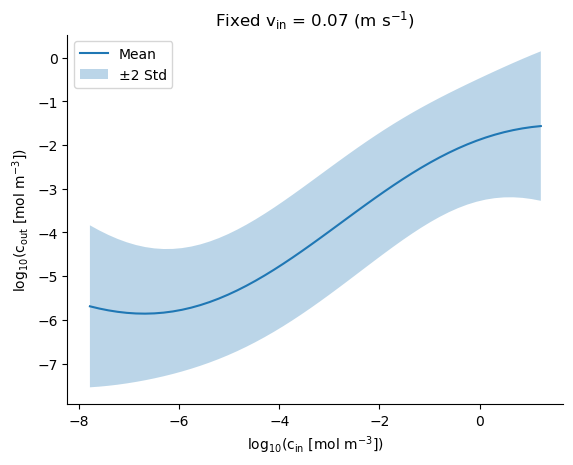

In [106]:
# plot 1d slice for fixed v_in, l, and r

n_points = 50
c_in_range = simulator.parameters_range["c_in"]

fixed_params = ["v_in", "bend_radius", "length"]
fixed_vals = {p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params}

c_in_vals = np.linspace(c_in_range[0], c_in_range[1], n_points)
c_in = np.column_stack([
    c_in_vals,
    np.full(n_points, fixed_vals["v_in"]),
    np.full(n_points, fixed_vals["bend_radius"]),
    np.full(n_points, fixed_vals["length"]),
])
c_in = torch.from_numpy(c_in).float()


y_mean, y_var = emulator.predict_mean_and_variance(c_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0] # c_out values
y_std_1d = np.sqrt(y_var[::2]) 

# actual plotting 
ax.plot(c_in_vals, y_mean_1d, label='Mean')
ax.fill_between(c_in_vals,
                y_mean_1d - 2*y_std_1d,
                y_mean_1d + 2*y_std_1d,
                alpha=0.3, label='±2 Std')
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_xlabel(r"log$_{10}$(c$_{\mathrm{in}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed v$_{\mathrm{in}}$ = 0.07 (m s$^{-1}$)")
# ax.set_ylim(-10, 5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("vin-fixed.pdf")
ax.legend()
plt.show()

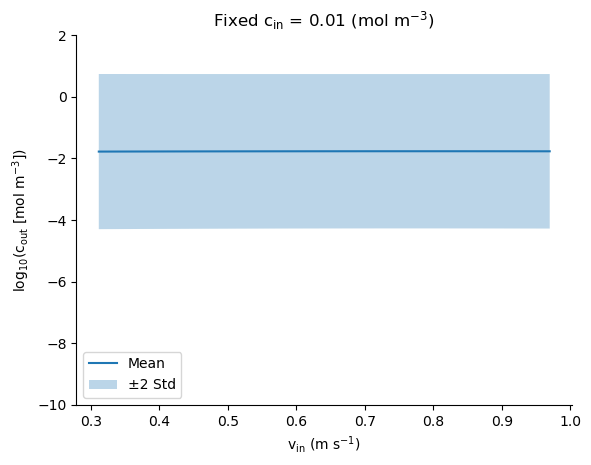

In [107]:
# plot 1d slice for fixed c_in, l, and r

n_points = 50
v_in_range = simulator.parameters_range["v_in"]

fixed_params = ["c_in", "bend_radius", "length"]
fixed_vals = {p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params}

v_in_vals = np.linspace(v_in_range[0], v_in_range[1], n_points)
v_in = np.column_stack([
    np.full(n_points, fixed_vals["c_in"]),
    v_in_vals,
    np.full(n_points, fixed_vals["bend_radius"]),
    np.full(n_points, fixed_vals["length"]),
])
v_in = torch.from_numpy(v_in).float()


y_mean, y_var = emulator.predict_mean_and_variance(v_in)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0] # c_out values
y_std_1d = np.sqrt(y_var[::2]) 

# actual plotting 
ax.plot(v_in_vals, y_mean_1d, label='Mean')
ax.fill_between(v_in_vals,
                y_mean_1d - 2*y_std_1d,
                y_mean_1d + 2*y_std_1d,
                alpha=0.3, label='±2 Std')
ax.set_xlabel(r"v$_{\mathrm{in}}$ (m s$^{-1}$)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
ax.set_ylim(-10, 2)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.savefig("cin-fixed.pdf")
ax.legend()
plt.show()

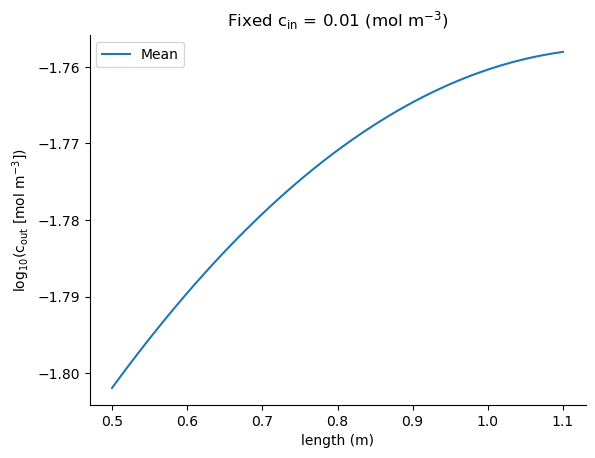

In [108]:
# plot 1d slice for fixed c_in, v_in, and r

n_points = 50
length_range = simulator.parameters_range["length"]

fixed_params = ["c_in", "bend_radius", "v_in"]
fixed_vals = {p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params}

length_vals = np.linspace(length_range[0], length_range[1], n_points)
length = np.column_stack([
    np.full(n_points, fixed_vals["c_in"]),
    np.full(n_points, fixed_vals["v_in"]),
    np.full(n_points, fixed_vals["bend_radius"]),
    length_vals,
])
length = torch.from_numpy(length).float()


y_mean, y_var = emulator.predict_mean_and_variance(length)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0] # c_out values
y_std_1d = np.sqrt(y_var[::2]) 

# actual plotting 
ax.plot(length_vals, y_mean_1d, label='Mean')
# ax.fill_between(length_vals,
#                 y_mean_1d - 2*y_std_1d,
#                 y_mean_1d + 2*y_std_1d,
#                 alpha=0.3, label='±2 Std')
ax.set_xlabel(r"length (m)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
# ax.set_ylim(-0.5, 0.5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("length-fixed.pdf")
ax.legend()
plt.show()

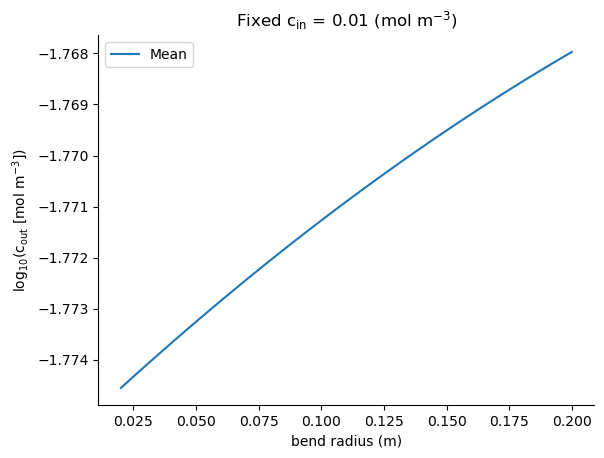

In [109]:
# plot 1d slice for fixed c_in, v_in, and length

n_points = 50
bend_radius_range = simulator.parameters_range["bend_radius"]

fixed_params = ["c_in", "length", "v_in"]
fixed_vals = {p: abs((param_bounds[p][0] + param_bounds[p][1]) / 2.0) for p in fixed_params}

bend_radius_vals = np.linspace(bend_radius_range[0], bend_radius_range[1], n_points)
bend_radius = np.column_stack([
    np.full(n_points, fixed_vals["c_in"]),
    np.full(n_points, fixed_vals["v_in"]),
    bend_radius_vals,
    np.full(n_points, fixed_vals["length"]),
])
bend_radius = torch.from_numpy(bend_radius).float()


y_mean, y_var = emulator.predict_mean_and_variance(bend_radius)
y_mean = np.array(y_mean)
y_var = np.array(y_var).flatten()

fig, ax = plt.subplots()

# plotting values 
y_mean_1d = y_mean[:, 0] # c_out values
y_std_1d = np.sqrt(y_var[::2]) 

# actual plotting 
ax.plot(bend_radius_vals, y_mean_1d, label='Mean')
# ax.fill_between(bend_radius_vals,
#                 y_mean_1d - 2*y_std_1d,
#                 y_mean_1d + 2*y_std_1d,
#                 alpha=0.3, label='±2 Std')
ax.set_xlabel(r"bend radius (m)")
ax.set_ylabel(r"log$_{10}$(c$_{\mathrm{out}}$ [mol m$^{-3}$])")
ax.set_title(r"Fixed c$_{\mathrm{in}}$ = 0.01 (mol m$^{-3}$)")
# ax.set_ylim(-0.5, 0.5)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.savefig("bend_radius-fixed.pdf")
ax.legend()
plt.show()